# 9회차 형태소 분석 실습1

목적

1. 형태소와 형태소 분석에 대해 배우고 이해한다.
2. KoNLPy 라이브러리와 분석기 종류 및 사용법에 대해 배우고 이해한다.
3. 분석된 데이터를 CSV 파일 포맷으로 저장하는 방법을 배우고 이해한다.

### 형태소와 형태소 분석

형태소란?
- 분석에서는 토근(token)이라고 한다.
- 형태소(morpheme)는 언어학에서 (일반적인 정의를 따르면) 일정한 의미가 있는 가장 작은 말의 단위로 발화체 내에서 따로 떼어낼 수 있는 것을 말한다. 즉, 더 분석하면 뜻이 없어지는 말의 단위이다.
- 어절보다는 작지만 그래도 의미를 가진 단위이다 예)명사, 조사, 어미

예1) "지구에" => [지구, 에]

예2) "지구를" => [지구, 를]


형태소 분석이란?
- 첫번째 단계는 토큰화(tokenize)
- 텍스트 토큰화(Text Tokenization)란 말뭉치로부터 토큰을 분리하는 작업이다
- 문장을 형태소 단위의 토큰으로 분리

예) This is an apple => 'this', 'is', 'an', 'apple'

문장 토큰화(Sentence Tokenization)

- 문장의 마침표(.), 개행문자(\n), 느낌표(!), 물음표(?) 등 문장의 마지막을 뜻하는 기호에 따라 분리하는 것
- 하지만, 다른 경우도 있다

영어 예제) Yes! They're Ph.D students.
- 답:"Yes", "They're Ph.D students"
- 실제 결과값:"Yes", "They're Ph", 'D students'

100% 정확하게 문장을 분리하는 것은 쉬운 일이 아니다.

한글 예제) 제 이메일은 me@email.com입니다.
- 답: "제 이메일은 me@email.com입니다"
- 실제 결과값:"제 이메일은 me@email", "com입니다"

### 한국어 띄어쓰기 토큰화 예제 실습 1

In [1]:
# 링크: https://movie.naver.com/movie/bi/mi/point.naver?code=191430
kor_text = '살인 용의자와 변호사가 주고받는 대화로 '\
'인해 달라지는 상황에 따라 얼굴을 바꾸는 배우들의 '\
'다양한 연기를 볼 수 있는 것 또한 장점이다'
print(kor_text.split()) 

['살인', '용의자와', '변호사가', '주고받는', '대화로', '인해', '달라지는', '상황에', '따라', '얼굴을', '바꾸는', '배우들의', '다양한', '연기를', '볼', '수', '있는', '것', '또한', '장점이다']


단순한 파이썬의 문자형(string)의 split()함수를 사용한 경우이다.

결과값:
['살인', '용의자와', '변호사가', '주고받는', '대화로', '인해', '달라지는', '상황에', '따라', '얼굴을', '바꾸는', '배우들의', '다양한', '연기를', '볼', '수', '있는', '것', '또한', '장점이다']

- 용의자와
- 변호사가
- 대화로
- 얼굴을
- 배우들의
- 연기를

위의 예제에서는 '와', '가', '로', '을', '를' 들이 붙어있어 이를 제거해주시 않으면 기계는 다른 의미의 단어로 인식하게 된다.

### 한국어 형태소 토큰화 예제 실습 2



링크: https://konlpy.org/ko/latest/api/konlpy.tag/#mecab-class

위와 같은 상황을 방지하기 위해서 한국어는 보편적으로 한글 '형태소 분석기'로 토큰화를 한다.
- mecab를 사용

MeCab 이란?
- 은전한닢 프로젝트에서 MeCab 엔진이 일본어와 한국어의 유사점으로 인해 한글 분석에도 동작하는 것을 확인하고 개발한 한국어 형태소 분석기


In [2]:
# ============================================================
#  [Colab] 형태소 분석기 설치
#   - konlpy : Kkma/Komoran/Hannanum/Okt 용 (자바 기반, Colab 내장 자바 사용)
#   - ekonlpy: Mecab 용 (pip 설치만으로 동작, 컴파일/런타임재시작 불필요 → Python 3.12 OK)
# ============================================================
!pip install konlpy ekonlpy


Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 115 (delta 11), reused 10 (delta 3), pack-reused 91
Receiving objects: 100% (115/115), 1.27 MiB | 4.08 MiB/s, done.
Resolving deltas: 100% (50/50), done.


### Mecab 은 eKoNLPy 로 사용합니다

Colab(Python 3.12)에서는 `konlpy.tag.Mecab` 의 시스템 설치가 자주 실패합니다.
그래서 pip 설치만으로 동작하는 **eKoNLPy** 의 Mecab 을 씁니다 (재시작 불필요).
혹시 import 에러가 나면 **[런타임] → [런타임 다시 시작]** 한 번만 하고 다시 실행하세요.

In [4]:
# Mecab: Colab에서는 konlpy 대신 eKoNLPy 사용 (위에서 !pip install ekonlpy 먼저)
try:
    from ekonlpy.tag import Mecab
except ImportError:
    from ekonlpy import Mecab
tokenizer = Mecab()
print(tokenizer.morphs(kor_text))


['살인', '용의자', '와', '변호사', '가', '주고받', '는', '대화', '로', '인해', '달라지', '는', '상황', '에', '따라', '얼굴', '을', '바꾸', '는', '배우', '들', '의', '다양', '한', '연기', '를', '볼', '수', '있', '는', '것', '또한', '장점', '이', '다']


MeCab를 사용한 결과값:

['살인', '용의자', '와', '변호사', '가', '주고받', '는', '대화', '로', '인해', '달라지', '는', '상황', '에', '따라', '얼굴', '을', '바꾸', '는', '배우', '들', '의', '다양', '한', '연기', '를', '볼', '수', '있', '는', '것', '또한', '장점', '이', '다']

- 용의자(와)
- 변호사(가)
- 대화(로)
- 얼굴(을)
- 배우(들)(의)
- 연기(를)

*단어들이 나누에 진것을 확인할 수 있다.

## KoNLPy 라이브러리 사용하기


KoNLPy란?
- "코엔엘파이"라고 읽으며. 한국어 자연어처리를 위한 파이썬 패키지입니다.
- korean natural language processing in python의 약자
- Ko는 한국어인 Korean
- NLP는 Natural Language Process의 줄임말로 '자연어'를 뜻함
- Py는 Python의 파이썬을 의미




꼬꼬마 (Kkma)
- Kkma는 서울대학교의 지능형 데이터 시스템(IDS) 연구소에서 개발한 자바로 작성된 형태학적 분석기 및 자연어 처리 시스템이다.
- pprint: 인코딩을 잡아주는 기능의 함수로 konlpy.utils에 포함되어 있다.

Komoran
- 자바 한국어 형태소 분석기 (Komoran): KOMORAN은 2013 년부터 Shineware가 개발 한 Java로 작성된 비교적 새로운 오픈 소스 한국어 형태 분석기이다

한나눔(Hannanum)
- JHannanum은 자바로 작성된 형태학적 분석기 및 POS(Part of Speech, 품사) 태거로, 1999년부터 KAIST의 시맨틱 웹 연구 센터(SWRC)에서 개발했습니다.

Okt, 'Open Korean Text'(Twitter)
- 스칼라로 쓰여진 한국어 처리기로. 현재 텍스트 정규화와 형태소 분석, 스테밍을 지원하고 있다. 짧은 트윗으로 시작해서 지금은 긴 글도 처리할 수 있다. (twitter-korean-text)

link: https://github.com/twitter/twitter-korean-text

은전한닢 프로젝트 (Mecab)
- 원래 교토대학교 정보학 대학원에서 개발한 일본의 형태학적 분석기이자 POS 태거인 MeCab은 한국어에 적응하기 위해 은전프로젝트(은전한닢 프로젝트, 오픈소스)에 의해 MeCab-ko로 수정되었다.
- 윈도우에서 사용불가한 단점이 있다.


In [5]:
## 설치하기
!pip install konlpy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [6]:
# -*- coding: utf-8 -*-

from konlpy.tag import Kkma
from konlpy.tag import Komoran
from konlpy.tag import Hannanum
from konlpy.tag import Okt

example = u'살인 용의자와 변호사가 주고받는 대화로 '\
'인해 달라지는 상황에 따라 얼굴을 바꾸는 배우들의 '\
'다양한 연기를 볼 수 있는 것 또한 장점이다'

taggers = [ ('꼬꼬마', Kkma()),
            ('코모란', Komoran()),
            ('트위터', Okt()),
            ('한나눔', Hannanum())]
            
####################################################
# 공통 함수 테스트
###################################################
for name,tagger in taggers:
    print('%s %s %s'%('-'*10,name,'-'*10))
    try:
        print(tagger.pos(example))    # 품사 태깅
        print(tagger.morphs(example)) # 형태소만 추출
        print(tagger.nouns(example))  # 명사 추출
    except Exception as e:
        print(e)

#####################################################
# 단독 함수 및 옵션 테스트
#####################################################
print('='*50)

# [ 꼬꼬마 ]
print( taggers[0][1].sentences( example ) ) # 문장 추출
# [ 코모란 ]
print('-'*25, '코모란','-'*25)
print( taggers[1][1].pos( phrase=example, flatten=False ) ) # flatten=False이면, 어절 단위 PoS Tagging
print( taggers[1][1].pos( phrase=example, flatten=True ) )  # 차이 비교용
# [ Okt(트위터) ]
print('-'*25, 'otk(트위터)','-'*25)
print( taggers[2][1].pos( phrase=example, norm=True, stem=True) ) # norm=True 이면, 토큰 노멀라이즈, stem=True 이면, 토큰 스테밍
print( taggers[2][1].pos( phrase=example, norm=False, stem=False) ) # 차이 비교용


---------- 꼬꼬마 ----------
[('살인', 'NNG'), ('용의자', 'NNG'), ('와', 'JC'), ('변호사', 'NNG'), ('가', 'JKS'), ('주고받', 'VV'), ('는', 'ETD'), ('대화', 'NNG'), ('로', 'JKM'), ('인하', 'VV'), ('어', 'ECS'), ('달라지', 'VV'), ('는', 'ETD'), ('상황', 'NNG'), ('에', 'JKM'), ('따르', 'VV'), ('아', 'ECS'), ('얼굴', 'NNG'), ('을', 'JKO'), ('바꾸', 'VV'), ('는', 'ETD'), ('배우', 'NNG'), ('들', 'XSN'), ('의', 'JKG'), ('다양', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETD'), ('연기', 'NNG'), ('를', 'JKO'), ('보', 'VV'), ('ㄹ', 'ETD'), ('수', 'NNB'), ('있', 'VV'), ('는', 'ETD'), ('것', 'NNB'), ('또한', 'MAG'), ('장점', 'NNG'), ('이', 'VCP'), ('다', 'EFN')]
['살인', '용의자', '와', '변호사', '가', '주고받', '는', '대화', '로', '인하', '어', '달라지', '는', '상황', '에', '따르', '아', '얼굴', '을', '바꾸', '는', '배우', '들', '의', '다양', '하', 'ㄴ', '연기', '를', '보', 'ㄹ', '수', '있', '는', '것', '또한', '장점', '이', '다']
['살인', '용의자', '변호사', '대화', '상황', '얼굴', '배우', '다양', '연기', '수', '장점']
---------- 코모란 ----------
[('살인', 'NNP'), ('용의자', 'NNP'), ('와', 'JC'), ('변호사', 'NNG'), ('가', 'JKS'), ('주고받', 'VV'), ('는', 'ETM'), (

한국어 품사및 태그
- 링크: https://velog.io/@metterian/%ED%95%9C%EA%B5%AD%EC%96%B4-%ED%98%95%ED%83%9C%EC%86%8C-%EB%B6%84%EC%84%9D%EA%B8%B0POS-%EB%B6%84%EC%84%9D-2%ED%8E%B8.-%ED%92%88%EC%82%AC-%ED%83%9C%EA%B7%B8-%EC%A0%95%EB%A6%AC


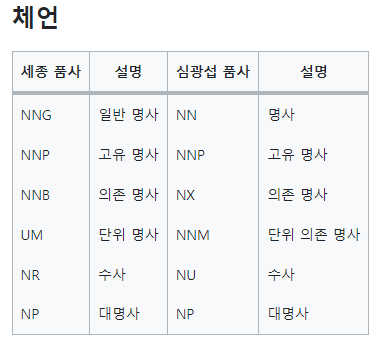

## CSV로 저장하기

In [2]:
## 설치하기
!pip install konlpy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 19.4 MB 5.8 MB/s 
     |████████████████████████████████| 465 kB 55.7 MB/s 


In [3]:
from konlpy.tag import Kkma
from konlpy.tag import Komoran
from konlpy.tag import Hannanum
from konlpy.tag import Okt

import pandas as pd

example = u'살인 용의자와 변호사가 주고받는 대화로 '\
'인해 달라지는 상황에 따라 얼굴을 바꾸는 배우들의 '\
'다양한 연기를 볼 수 있는 것 또한 장점이다'

taggers = [ ('꼬꼬마', Kkma()),
            ('코모란', Komoran()),
            ('트위터', Okt()),
            ('한나눔', Hannanum())]

df = pd.DataFrame();

for name,tagger in taggers:
    print('%s %s %s'%('-'*10,name,'-'*10))
    try:
        df[name] = pd.Series(tagger.morphs(example))
        #print(tagger.pos(example))    # 품사 태깅
        #print(tagger.morphs(example)) # 형태소만 추출
        #print(tagger.nouns(example))  # 명사 추출
    except Exception as e:
        print(e)

# 판다스 데이터 프레임으로 Excel로 저장(export)하는 방법
df.to_excel('./okt.xlsx', sheet_name='Sheet1')

# CSV로 저장(export)하는 방법
df.to_csv('./okt.csv', index = False, header=True)

---------- 꼬꼬마 ----------
---------- 코모란 ----------
---------- 트위터 ----------
---------- 한나눔 ----------
